In [34]:
%load_ext autoreload
%autoreload 2

import nest_asyncio
nest_asyncio.apply()

import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("ggplot")
pylab.rcParams.update({
    "legend.fontsize": "medium", "figure.figsize": (18, 6),
    "axes.labelsize": "medium", "axes.titlesize": "medium",
    "xtick.labelsize": "medium", "ytick.labelsize": "medium",
})

import datetime
import os
import sys

import numpy as np
import pandas as pd
import pytz

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
NYC_tz = pytz.timezone("America/New_York")
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from TB.IRSwaptionsTB import IRSwaptionsTB
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

# curve_mdp = IRSwapsMDP(source="CITIVELO_EXCEL")
curve_mdp = IRSwapsMDP(source="citivelo_excel_rl")
usts_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-RL")
vol_mdp = IRSwaptionMDP(
    source="CITIVELO-RL",
    curve_source="citivelo_excel_rl",
    request_defaults={"verify": False},
)

start = datetime.date(2023, 1, 1)
end = datetime.date(2026, 8, 24)

In [36]:
COLOURS = ["WHITES", "REDS", "GREENS", "BLUES", "GOLDS"]
COLOURS_MODEL = ["WHITES_MODEL", "REDS_MODEL", "GREENS_MODEL", "BLUES_MODEL", "GOLDS_MODEL"]
ca_df = IRSwapsTB(curve_mdp, show_tqdm=True).sfr_cvx_adj(COLOURS + COLOURS_MODEL, start, end)
ca_df


,USD-SOFR-1D WHITES_MODEL PACKS CVX_ADJ,USD-SOFR-1D REDS_MODEL PACKS CVX_ADJ,USD-SOFR-1D GREENS_MODEL PACKS CVX_ADJ,USD-SOFR-1D BLUES_MODEL PACKS CVX_ADJ,USD-SOFR-1D GOLDS_MODEL PACKS CVX_ADJ,USD-SOFR-1D WHITES PACKS CVX_ADJ,USD-SOFR-1D REDS PACKS CVX_ADJ,USD-SOFR-1D GREENS PACKS CVX_ADJ,USD-SOFR-1D BLUES PACKS CVX_ADJ,USD-SOFR-1D GOLDS PACKS CVX_ADJ
Date,,,,,,,,,,
2023-01-03,0.344611,2.569541,6.404078,11.261601,16.416603,1.000979,5.443960,5.071216,10.737595,18.278549
2023-01-04,0.326642,2.440525,6.121076,10.881983,15.951156,2.551794,3.963245,5.257072,12.511351,19.358071
2023-01-05,0.298203,2.281445,5.810810,10.315825,14.961574,0.913003,6.279041,4.994146,12.386524,20.988248
2023-01-06,0.274758,2.108170,5.398788,9.657205,14.195847,1.056826,4.859519,5.521231,11.559818,18.256925
2023-01-09,0.265222,2.003902,5.099018,9.091265,13.498074,1.187043,4.280657,6.113516,13.429119,20.662487
...,...,...,...,...,...,...,...,...,...,...
2026-08-18,0.109622,1.011174,2.783246,5.324618,8.549746,0.186018,0.787803,2.620597,6.171205,9.484143
2026-08-19,0.107754,0.974959,2.718713,5.206032,8.357875,1.780621,-0.782571,2.623165,5.997563,9.439120
2026-08-20,0.108230,1.004945,2.776374,5.327434,8.541127,0.349620,0.559957,2.624418,6.647986,9.933550


In [31]:
df = TimeseriesBuilder().get_timeseries(
    start=start,
    end=end,
    queries=[
        # UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="IMM_1x2y/IMM_1x5y/IMM_1x10y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
		# UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="IMM_2x2y/IMM_2x5y/IMM_2x10y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
		# UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="IMM_1x5y/IMM_1x10y/IMM_1x30y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
		# UnifiedQuery(
        #     curve="USD-SOFR-1D",
        #     tenor="IMM_2x5y/IMM_2x10y/IMM_2x30y",
        #     value=UnifiedValue.IRS_RATE,
        # ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="10y10y/20y10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="10y10y/15y10y",
            value=UnifiedValue.IRS_RATE,
        ),
		UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="IMM_3xIMM_4",
            value=UnifiedValue.IRS_RATE,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="1y1y",
            value=UnifiedValue.IRS_RATE,
        ),
        UnifiedQuery(
            curve="USD-SOFR-1D",
            tenor="1d",
            value=UnifiedValue.IRS_RATE,
        ),
		# UnifiedQuery(
		# 	curve="USD-SOFR-1D",
		# 	selector={"shorthand":  "1Yx1Y", "strike": "ATMF"},
		# 	structure=UnifiedStructure.IRSWAPTION_STRADDLE,
		# 	value=UnifiedValue.IRSWAPTION_NVOL,
		# ),
		# UnifiedQuery(
		# 	curve="USD-SOFR-1D",
		# 	selector={"shorthand":  "2Yx1Y", "strike": "ATMF"},
		# 	structure=UnifiedStructure.IRSWAPTION_STRADDLE,
		# 	value=UnifiedValue.IRSWAPTION_NVOL,
		# ),
		# UnifiedQuery(
		# 	curve="USD-SOFR-1D",
		# 	selector={"shorthand":  "3Yx1Y", "strike": "ATMF"},
		# 	structure=UnifiedStructure.IRSWAPTION_STRADDLE,
		# 	value=UnifiedValue.IRSWAPTION_NVOL,
		# ),
		# UnifiedQuery(
		# 	curve="USD-SOFR-1D",
		# 	selector={"shorthand":  "4Yx1Y", "strike": "ATMF"},
		# 	structure=UnifiedStructure.IRSWAPTION_STRADDLE,
		# 	value=UnifiedValue.IRSWAPTION_NVOL,
		# ),
    ],
    n_jobs=18,
    routers={
        "IRS": IRSwapsTB(curve_mdp, show_tqdm=True),
        "FRB": FixedRateBondsTB(usts_mdp, show_tqdm=True),
        "IRSWAPTION":  IRSwaptionsTB(vol_mdp, show_tqdm=True),
    },
)
df

SUCCESS: `func_tol` reached after 6 iterations (levenberg_marquardt), `f_val`: 2.992044211390146e-13, `time`: 0.1302s


,USD-SOFR-1D 10y10y/15y10y CURVE RATE,USD-SOFR-1D 10y10y/20y10y CURVE RATE,USD-SOFR-1D 1d OUTRIGHT RATE,USD-SOFR-1D 1y1y OUTRIGHT RATE,USD-SOFR-1D IMM_3xIMM_4 OUTRIGHT RATE
Date,,,,,
2023-01-03,-42.356992,-87.901363,4.30000,3.940596,4.783700
2023-01-04,-41.134915,-86.176790,4.31000,3.916028,4.785284
2023-01-05,-42.208144,-87.099715,4.31000,3.980258,4.889799
2023-01-06,-41.305580,-85.453248,4.31000,3.692994,4.754545
2023-01-09,-40.475016,-81.097429,4.31000,3.609282,4.696841
...,...,...,...,...,...
2026-08-18,-15.847600,-55.446459,3.63200,4.083505,4.018075
2026-08-19,-15.365212,-55.387122,3.62815,4.111123,3.996585
2026-08-20,-16.084102,-55.485193,3.63759,4.113080,4.010155


In [24]:
import sys
sys.path.append("../../")
sys.path.append("../rv")

import dataclasses

import fed_expected_sentiment as E
import fed_event_conditioning as FEC

RATE_START = datetime.date(2015, 1, 1)
SENT_START = datetime.date(2023, 5, 1)
END = datetime.date(2026, 8, 24)

zc, comp_prov = E.load_composite()                      # weekly W-FRI, z-scored
zc = zc.dropna()
cfg = dataclasses.replace(FEC.PRIMARY, source="jpm")
sent_df, scores = FEC.load_daily_sentiment(cfg, str(SENT_START), str(END))
sent_df = sent_df.dropna()
sent_df
# sent = sent_df["sentiment"].dropna()                    # raw index, the JWS scale
# sent

,sentiment,n_speeches,newest_age_days,z
2023-10-25,11.963270,53,5.0,-0.872914
2023-10-26,11.936308,50,6.0,-0.874773
2023-10-27,11.918011,49,7.0,-0.874123
2023-10-30,11.994661,47,10.0,-0.845680
2023-10-31,11.994661,47,11.0,-0.840121
...,...,...,...,...
2026-08-18,29.545738,42,5.0,2.826589
2026-08-19,29.545738,42,6.0,2.774101
2026-08-20,29.545738,42,7.0,2.724061
2026-08-21,29.609608,41,8.0,2.682337


In [16]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly", 
	# ylabel_left="convexity adjustment, bp",
    # title="SFR convexity adjustment by pack colour"
)

# plot(ca_df["USD-SOFR-1D GREENS PACKS CVX_ADJ"].dropna(), which="left")
plot(ca_df["USD-SOFR-1D GOLDS PACKS CVX_ADJ"].dropna(), which="left")
plot(ca_df["USD-SOFR-1D GOLDS_MODEL PACKS CVX_ADJ"].dropna(), which="left")
# plot(ca_df["USD-SOFR-1D GOLDS PACKS CVX_ADJ"].dropna(), which="left")

# plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D 3Yx1Y STRADDLE BUY ATMF NVOL"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_2x2y/IMM_2x5y/IMM_2x10y FLY RATE"].dropna(), which="right")
# plot(df["USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE"].dropna(), which="right")
# plot(df["USD-SOFR-1D 10y10y/15y10y CURVE RATE"].dropna(), which="right")
legend(show_date=True)

                                  OLS Regression Results                                  
Dep. Variable:     USD-SOFR-1D 1y1y OUTRIGHT RATE   R-squared:                       0.472
Model:                                        OLS   Adj. R-squared:                  0.471
Method:                             Least Squares   F-statistic:                     444.1
Date:                            Tue, 25 Aug 2026   Prob (F-statistic):           7.00e-71
Time:                                    17:08:43   Log-Likelihood:                -71.811
No. Observations:                             498   AIC:                             147.6
Df Residuals:                                 496   BIC:                             156.0
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------

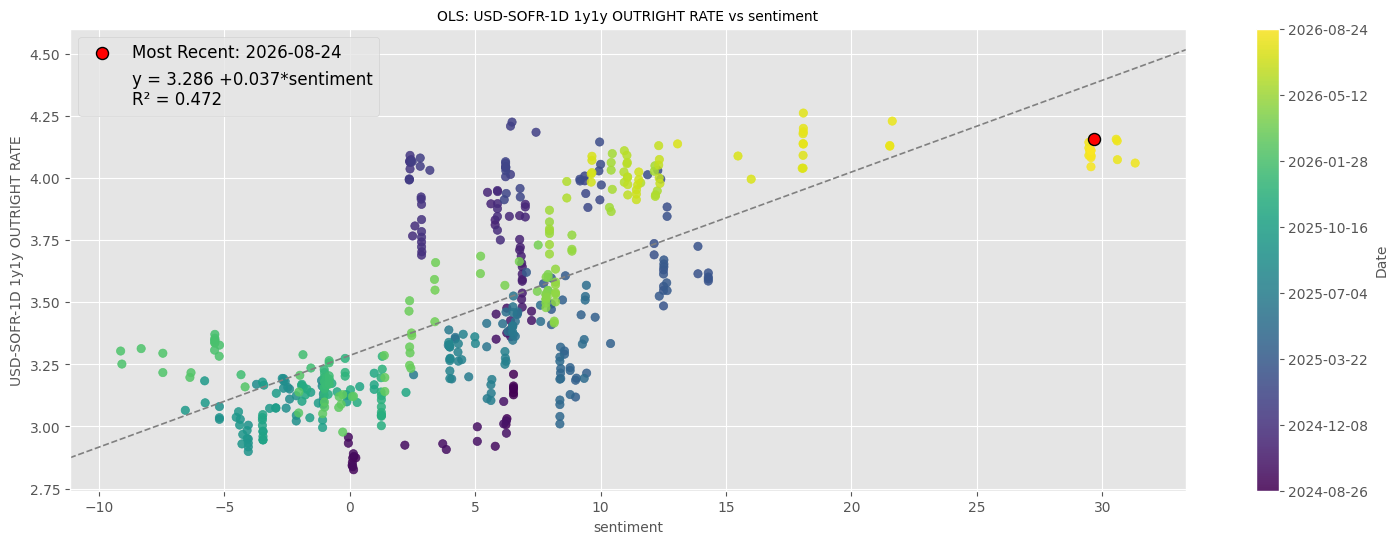

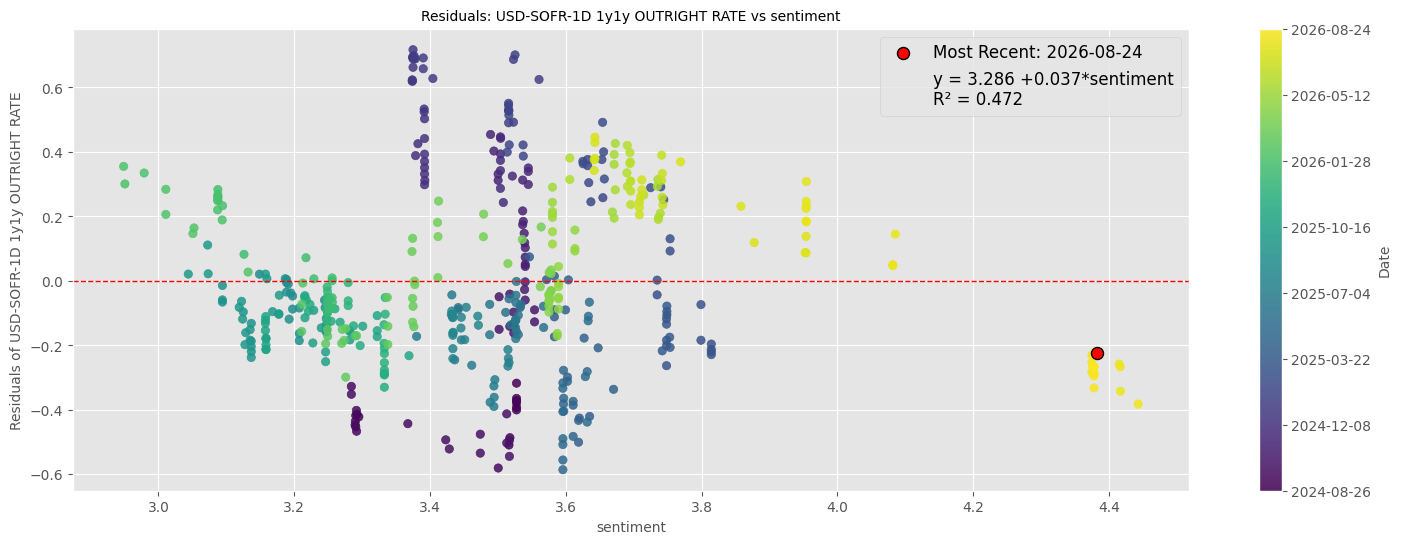

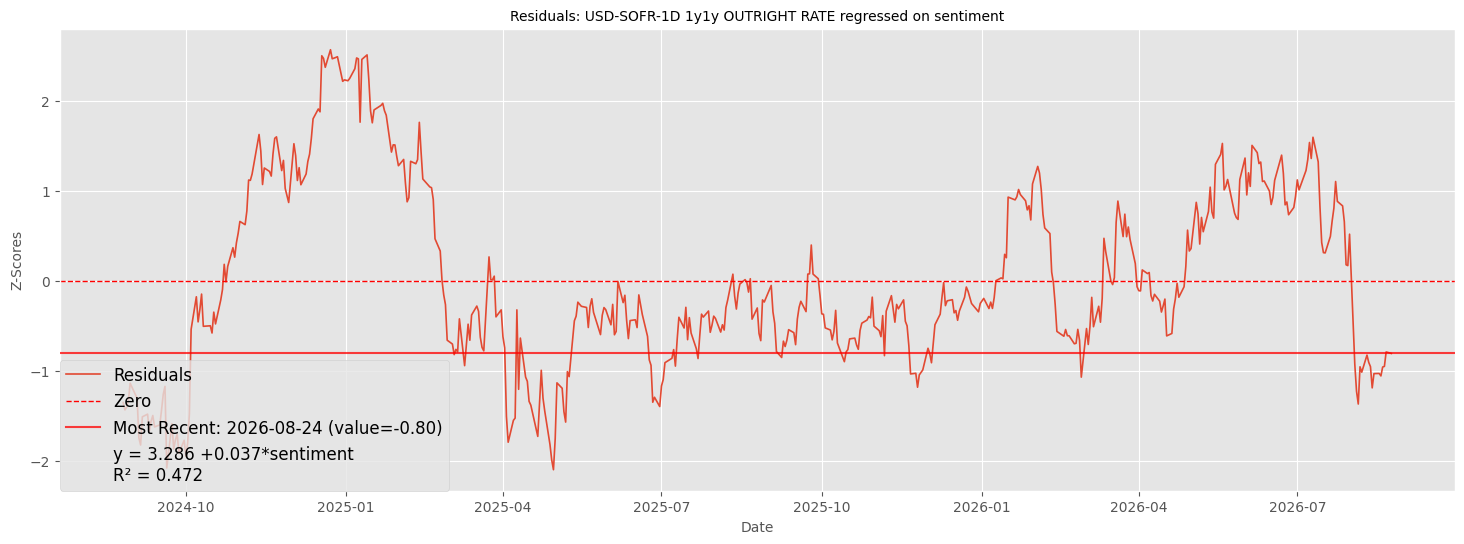

In [46]:
from RVUtils.regression import make_linear_regression_builder

# regression_df = pd.merge(ca_df, df, left_index=True, right_index=True) 

as_of = datetime.date(2024, 8, 24)
regression_df = pd.merge(df[df.index >= as_of], sent_df[sent_df.index > pd.Timestamp(as_of)], left_index=True, right_index=True) 

add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, plot_residuals_timeseries, get_data = make_linear_regression_builder(
    df=regression_df,
    y_col="USD-SOFR-1D 1y1y OUTRIGHT RATE",
    # y_col="USD-SOFR-1D IMM_3xIMM_4 OUTRIGHT RATE",
    date_color_bar=True,
	# on_diff=True
)
# add_indep_var("USD-SOFR-1D IMM_1x2y/IMM_1x5y/IMM_1x10y FLY RATE")
# add_indep_var("USD-SOFR-1D IMM_1x5y/IMM_1x10y/IMM_1x30y FLY RATE")
add_indep_var("sentiment")
# add_indep_var("USD-SOFR-1D 1d OUTRIGHT RATE")
res = fit(model="OLS", verbose=True)
# res = fit(model="SIGMOID", verbose=True)
plot_actual_vs_predicted()
plot_residuals_vs_predicted()
# plot_residuals_timeseries(plot_zscores=True, plot_zero=True, stds=[1, 2])
plot_residuals_timeseries(plot_zscores=True, plot_zero=True, ou_bands=False)


In [ ]:
latest = ca_df.dropna(how="all").iloc[-1]
asof = ca_df.dropna(how="all").index[-1]
print(f"as of {asof.date()}")
print(latest.reindex(COLOURS).round(3).to_string())

import plotly.graph_objects as go
_c = latest.reindex(COLOURS).dropna()
f2 = go.Figure(go.Bar(x=_c.index, y=_c.to_numpy(),
                      text=[f"{v:.2f}" for v in _c], textposition="outside"))
f2.update_layout(title=f"SFR convexity adjustment by colour, {asof.date()}",
                 yaxis_title="bp", height=380)
f2.show()

as of 2026-08-20
WHITES    0.350
REDS      0.560
GREENS    2.624
BLUES     6.648
GOLDS     9.934
